# Exploratory Data Analysis: 

The provided Jupyter notebook explores various aspects of Apple's stock data over a span of five years, integrating technical analysis, sentiment analysis, and the correlation of financial metrics with stock price movements. The analysis begins with a time series examination of AAPL's closing prices, highlighting an overall upward trajectory despite periods of significant volatility. These fluctuations are potentially linked to market events or specific news about the company, underlining the influence of external factors on stock prices.

The study also goes into trading volumes, observing a pattern of higher volumes at the beginning of the year, which possibly aligns with Apple's financial reporting and major product announcements. This seasonal trend suggests that investor interest in Apple peaks around these times, likely in anticipation of new product impacts or financial health indicators. Moreover, the exploration of sentiment analysis reveals that despite the presence of a composite sentiment score, its correlation with short-term, mid-term, and long-term stock price changes remains weak, indicating that sentiment alone may not be a reliable predictor of stock movements. This part of the analysis emphasizes the complexity of market dynamics and the challenge of using sentiment data to forecast stock prices accurately.

## Key Findings: 

#### Time Series Analysis:
- A steady upward trend in AAPL's stock price is highlighted with significant volatility. This suggests that while the general trajectory for Apple's stock is upward, it is susceptible to sharp fluctuations likely triggered by market-wide events or specific corporate news.


#### Volume Trends:
- Trading volumes showed distinct seasonal patterns, with peaks typically in January, possibly reflecting investor reactions to fiscal reports and major product releases. This indicates that trading activity might be influenced by anticipated company performances and strategic announcements.


#### Sentiment Analysis:
- The correlation between composite sentiment scores and subsequent stock price changes (over 1-day, 5-day, and 30-day periods) was found to be weak. This implies that sentiment, as derived from news articles, may not be a strong predictor of immediate or future stock prices.

#### Technical Indicators:
- Technical analysis using indicators such as SMA, EMA, RSI, MACD, and the Golden Cross revealed weak correlations with future stock price changes. These findings suggest that while these indicators can describe past market behaviors, their predictive power for future price movements is limited.


#### Correlation Analysis:
- A detailed correlation study between financial metrics and AAPL stock price changes showed that operational costs and cash flows had the most significant immediate impact on stock prices. This correlation diminishes over longer periods, indicating that different factors may influence the stock price depending on the time horizon.


#### Market Data Analysis:
- The correlation matrix for SPY and AAPL demonstrated minimal direct influence of broader market trends on AAPL's stock movements in the short term. However, AAPL's stock showed some internal consistency, suggesting that its short-term movements could slightly predict longer-term performance.

## Load Necessary Packages

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import textwrap
# from mplfinance.original_flavor import candlestick_ohlc
from sklearn.preprocessing import StandardScaler

# Load the dataset
aapl_master_data = pd.read_csv('AAPL_MasterData- 2018-2023.csv')

# Convert 'Date' to datetime format for better plotting
aapl_master_data['Date'] = pd.to_datetime(aapl_master_data['Date'])

# Set the display option to show full column length
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [98]:
aapl_master_data.head()

,Date,FinancialDateReporting,FilingDate,AAPL_Close,Close_Next_1_Day,Close_Next_5_Days,Close_Next_30_Days,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg,composite_sentiment_score,SMA_20,EMA_20,RSI,Golden_Cross,MACD,MACD_Signal,CurrentRatio,QuickRatio,DebtToEquityRatio,GrossMargin,OperatingMargin,NetProfitMargin,ReturnOnAssets,ReturnOnEquity,EPS,BasicEPS,DilutedEPS,DebtServiceCoverageRatio,FixedChargeCoverageRatio,SPY_Close,SPY_Volume,AAPL_Volume,FEDFUNDS,TotalRevenue,CostOfRevenue,GrossProfit,OperatingExpense,OperatingIncome,PretaxIncome,TotalAssets,OperatingCashFlow,InvestingCashFlow,CapitalExpenditure,FinancingCashFlow,ChangeInAccountPayable,AccountsPayable,AvailableForSaleSecurities,CashEquivalents,CashFinancial,ChangeInPayable,ChangesInAccountReceivables,OtherCurrentBorrowings,AccountsReceivable,AccumulatedDepreciation,CashAndCashEquivalents,ChangeInInventory,ChangeInOtherCurrentLiabilities,ChangeInOtherWorkingCapital,CurrentDebt,CurrentDeferredRevenue,DepreciationAndAmortization,GrossPPE,InvestmentinFinancialAssets,LongTermDebt,NetIncomeContinuousOperations,NetLongTermDebtIssuance,NetShortTermDebtIssuance,OtherEquityAdjustments,OtherInvestments,OtherReceivables,OtherShortTermInvestments,Payables,PurchaseOfBusiness,PurchaseOfInvestment,PurchaseOfPPE,SaleOfInvestment,CapitalStock,CashCashEquivalentsAndShortTermInvestments,ChangeInWorkingCapital,CurrentDebtAndCapitalLeaseObligation,CurrentDeferredLiabilities,DepreciationAmortizationDepletion,GainsLossesNotAffectingRetainedEarnings,Inventory,InvestmentsAndAdvances,LongTermDebtAndCapitalLeaseObligation,NetCommonStockIssuance,NetIncomeFromContinuingOperations,NetIncomeIncludingNoncontrollingInterests,NetInvestmentPurchaseAndSale,NetIssuancePaymentsOfDebt,NetOtherFinancingCharges,NetOtherInvestingChanges,NetPPE,NetPPEPurchaseAndSale,OtherCurrentAssets,OtherNonCurrentLiabilities,PayablesAndAccruedExpenses,Receivables,RetainedEarnings,StockBasedCompensation,BeginningCashPosition,CashFlowFromContinuingFinancingActivities,CashFlowFromContinuingInvestingActivities,CashFlowFromContinuingOperatingActivities,ChangesInCash,CurrentAssets,CurrentLiabilities,NetIncome,OperatingRevenue,ResearchAndDevelopment,SellingGeneralAndAdministration,TotalNonCurrentAssets,TotalNonCurrentLiabilitiesNetMinorityInterest,BasicAverageShares,CommonStockEquity,DilutedAverageShares,DilutedNIAvailtoComStockholders,EBIT,EBITDA,EndCashPosition,FreeCashFlow,NetDebt,NetIncomeCommonStockholders,NetIncomeFromContinuingAndDiscontinuedOperation,NetIncomeFromContinuingOperationNetMinorityInterest,NormalizedEBITDA,NormalizedIncome,OrdinarySharesNumber,OtherIncomeExpense,TotalCapitalization,TotalDebt,TotalExpenses,TotalLiabilitiesNetMinorityInterest,TotalOperatingIncomeAsReported,WorkingCapital
0,2018-01-02,12/31/2017,11/3/2017,43.065,43.057,43.583,41.842,-0.017,1.202,-2.839,0.0,42.99000,42.988,48.883,0.0,0.097,0.220,0.11,-0.1,0.87,0.38,0.3,0.23,0.05,0.14,0.97,0.98,0.97,0.19,18.4,268.769989,86655700.0,102223600.0,1.41,8.829300e+10,5.438100e+10,3.391200e+10,7.638000e+09,2.627400e+10,2.703000e+10,4.070000e+11,2.829300e+10,-1.359000e+10,-2.810000e+09,-7.501000e+09,1.260200e+10,6.298500e+10,2.079440e+11,1.796200e+10,9.529000e+09,1.260200e+10,-5.570000e+09,6.498000e+09,2.344000e+10,-4.343100e+10,2.749100e+10,434000000.0,3.975700e+10,569000000.0,1.847800e+10,8.044000e+09,2.745000e+09,7.711000e+10,2.079440e+11,1.039220e+11,2.006500e+10,6.969000e+09,2000000.0,-841000000.0,2.079440e+11,2.745900e+10,4.966200e+10,6.298500e+10,-173000000.0,-4.141300e+10,-2.810000e+09,3.084900e+10,3.644700e+10,7.715300e+10,3.793500e+10,1.847800e+10,8.044000e+09,2.745000e+09,-841000000.0,4.421000e+09,2.079440e+11,1.039220e+11,-1.009500e+10,2.006500e+10,2.006500e+10,-1.056400e+10,6.971000e+09,-1.038000e+09,-43000000.0,3.367900e+10,-2.810000e+09,1.133700e+10,8.293000e+09,8.926600e+10,5.089900e+10,1.045930e+11,1.296000e+09,2.028900e+10,-7.501000e+09,-1.359000e+10,2.829300e+10,7.202000e+09,1.438100e+11,1.157880e+11,2.006500e+10,8.829300e+10,3.407

## 1. Time Series Analysis: AAPL Closing Prices

#### Key Findings:

The line chart showcases a general upward trend in stock value over the five-year period. The graph highlights significant volatility, with noticeable peaks and troughs that may correspond to market events or company-specific news. Overall, the trend indicates growth in Apple's stock, described by periods of rapid gains and some corrections, reflecting investor confidence and market dynamics influencing the tech giant's valuation.

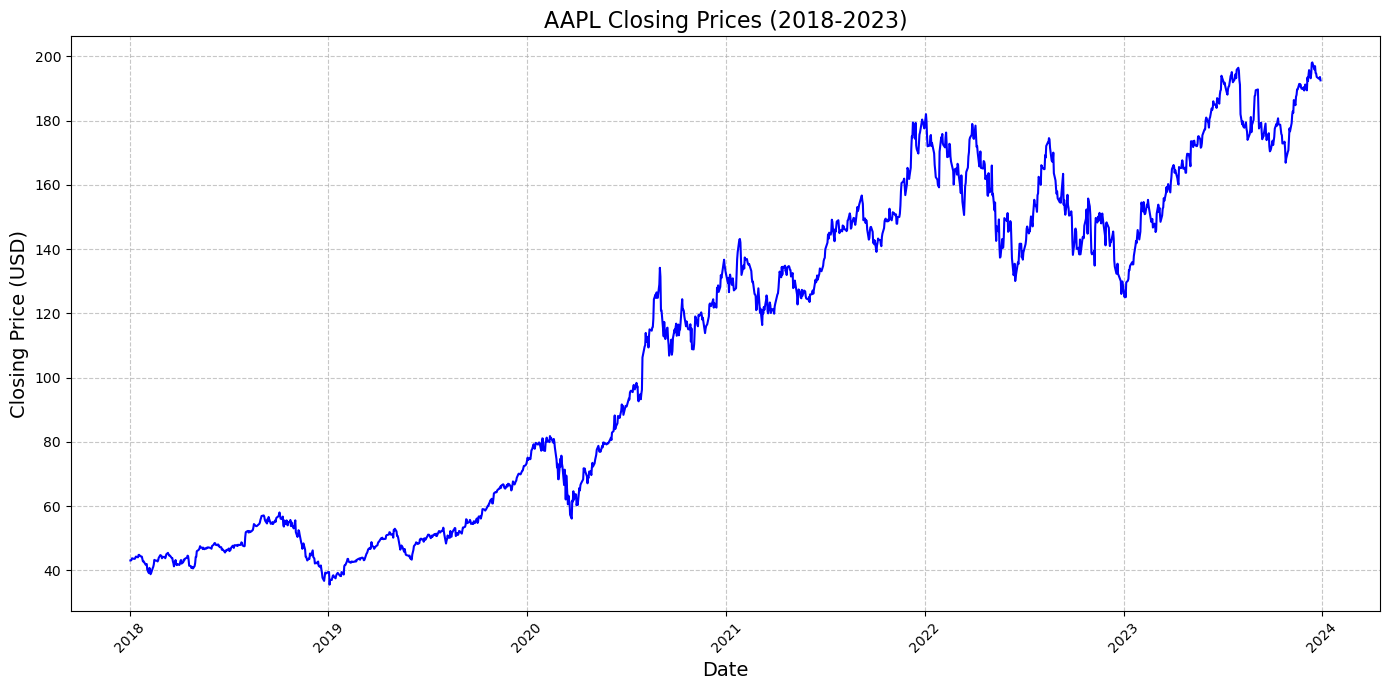

In [4]:
# Set the date as the index for easier plotting
aapl_master_data.set_index('Date', inplace=True)

# Line plot with additional features
plt.figure(figsize=(14, 7))
sns.lineplot(data=aapl_master_data, x=aapl_master_data.index, y='AAPL_Close', linestyle='-', color='blue')
plt.title('AAPL Closing Prices (2018-2023)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Closing Price (USD)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Volume Traded: Heatmap

#### Key Findings: 

There is a noticeable trend of higher trading volumes in the earlier months of the year, particularly in January, with volumes gradually decreasing into the mid-year before picking up again towards year-end. This pattern may indicate seasonal trends in trading behavior or could reflect market reactions to annual financial reports and major product announcements typically made by Apple during these periods.

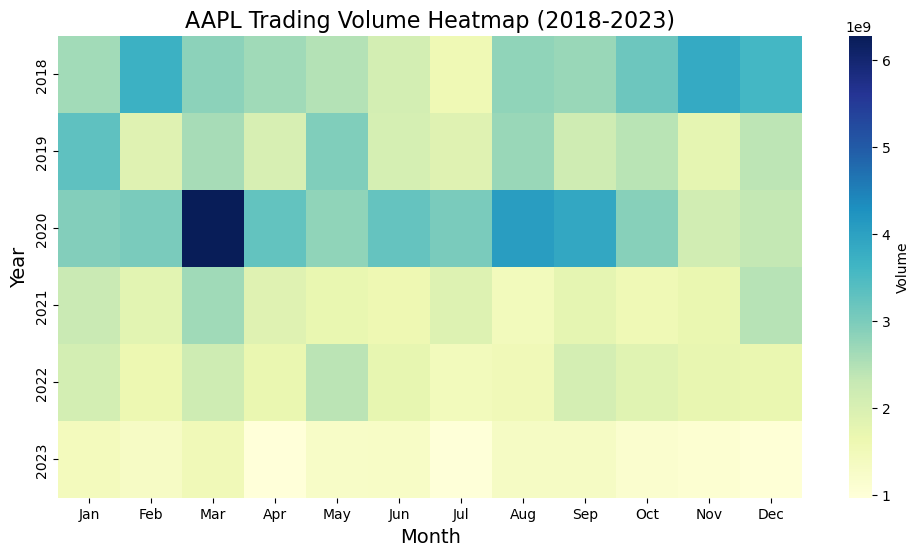

In [5]:
# Resample data to monthly frequency to observe trends
monthly_volume = aapl_master_data['AAPL_Volume'].resample('M').sum()

# Create a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_volume.values.reshape(-1, 12), cmap='YlGnBu', annot=False, cbar_kws={'label': 'Volume'})
plt.title('AAPL Trading Volume Heatmap (2018-2023)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.xticks(ticks=np.arange(12) + 0.5, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.yticks(ticks=np.arange(len(monthly_volume.index.year.unique())) + 0.5, labels=monthly_volume.index.year.unique())
plt.show()

## 3. Log Transformed Percentage Change Distribution of AAPL Stock
#### Key Findings: 
The histograms indicate left skewness across all the Close_Next percentage change distributions, suggesting that declines in stock prices are more frequent or pronounced over these periods than the increases, especially as the timeframe extends. This observation highlights an asymmetry in price movements, which could be indicative of prevailing market caution or negative sentiment over these intervals.

C:\Users\matt_\anaconda3\lib\site-packages\pandas\core\arraylike.py:397: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


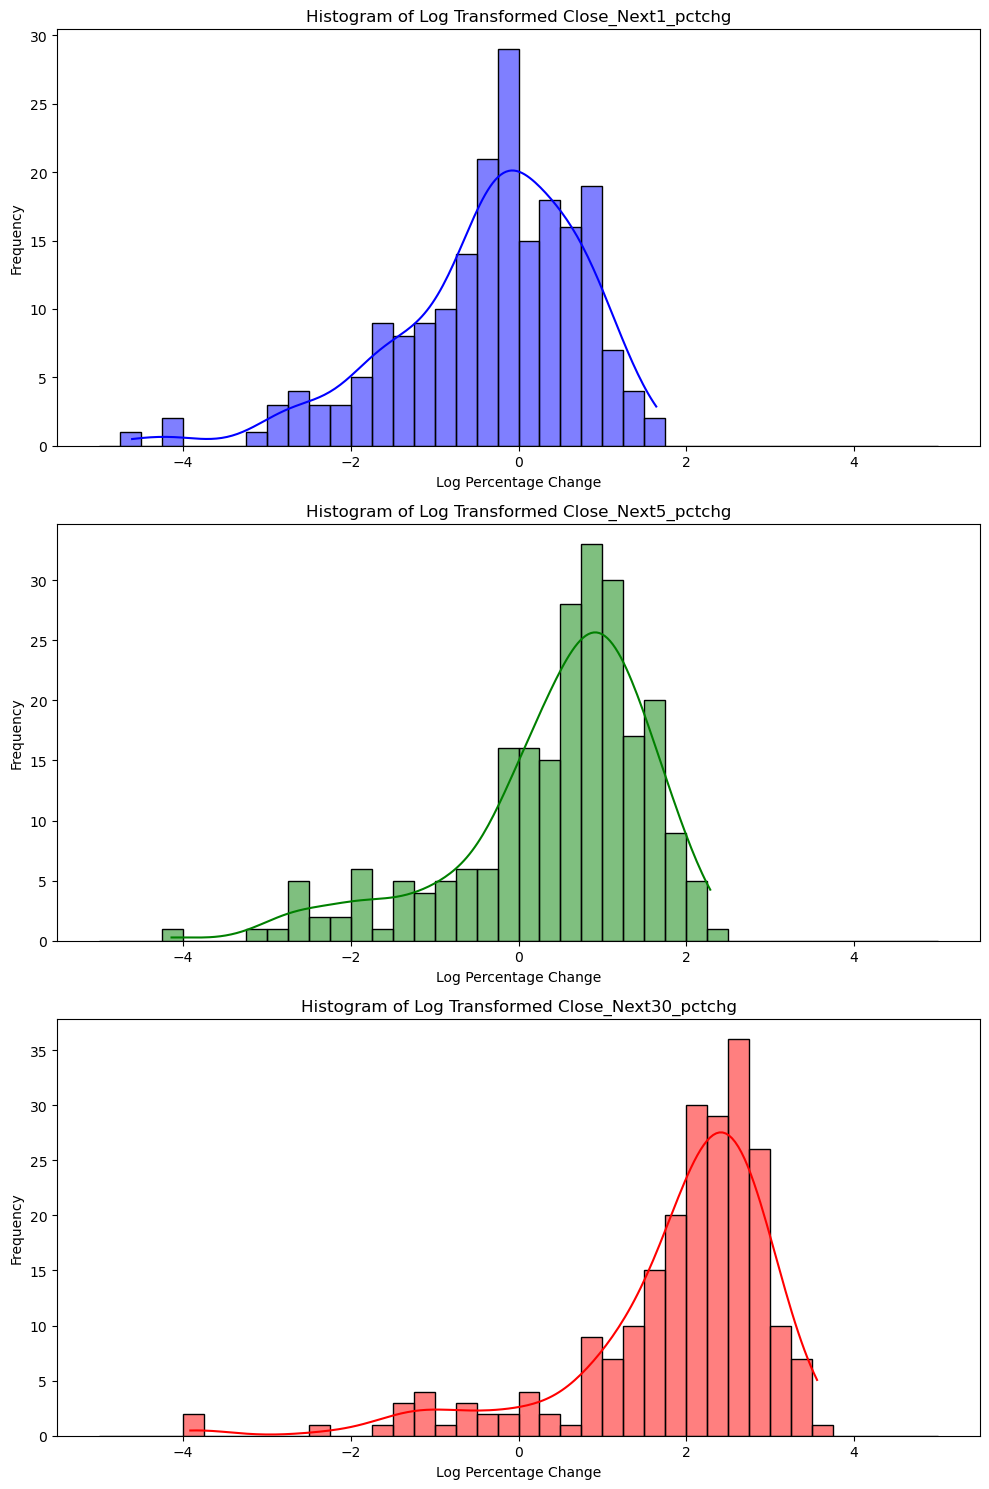

In [22]:
# Ensure no zero values before log transformation (shift the data)
shift_value = 0.01  # A small value to shift data to ensure positivity
aapl_master_data['Log_Close_Next1_pctchg'] = np.log(aapl_master_data['Close_Next1_pctchg'] + shift_value)
aapl_master_data['Log_Close_Next5_pctchg'] = np.log(aapl_master_data['Close_Next5_pctchg'] + shift_value)
aapl_master_data['Log_Close_Next30_pctchg'] = np.log(aapl_master_data['Close_Next30_pctchg'] + shift_value)

# Define the histogram bin edges (customize these as needed for better data representation)
bins = np.linspace(-5, 5, 41)  # Adjust the range and number of bins based on the transformed data

# Create a figure and axes for the subplots
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Histogram for Log_Close_Next1_pctchg
sns.histplot(aapl_master_data['Log_Close_Next1_pctchg'], bins=bins, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Histogram of Log Transformed Close_Next1_pctchg')
ax[0].set_xlabel('Log Percentage Change')
ax[0].set_ylabel('Frequency')

# Histogram for Log_Close_Next5_pctchg
sns.histplot(aapl_master_data['Log_Close_Next5_pctchg'], bins=bins, kde=True, ax=ax[1], color='green')
ax[1].set_title('Histogram of Log Transformed Close_Next5_pctchg')
ax[1].set_xlabel('Log Percentage Change')
ax[1].set_ylabel('Frequency')

# Histogram for Log_Close_Next30_pctchg
sns.histplot(aapl_master_data['Log_Close_Next30_pctchg'], bins=bins, kde=True, ax=ax[2], color='red')
ax[2].set_title('Histogram of Log Transformed Close_Next30_pctchg')
ax[2].set_xlabel('Log Percentage Change')
ax[2].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

## 4. Top Negative and Positive Correlations with AAPL Closing Price Change

#### Key Findings:

The charts illustrating the top correlations with Apple's closing price changes over 1-day, 5-day, and 30-day periods reveal key financial metrics that influence stock price movements. 

- For the 1-day changes, operational costs and cash flows show strong negative and positive correlations respectively, suggesting that operational efficiency and liquidity are immediate indicators of stock price movement. 
- Over a 5-day span, higher costs and lower margins negatively impact the stock, while strategic financial management like long-term investments enhances it. 
- For the 30-day outlook, increased liabilities and inventory levels correlate negatively, indicating that financial health and efficient inventory management are critical for longer-term price appreciation. Positive trends in liquidity and sales volume over this period further underscore the importance of robust operational and financial health in influencing Apple's stock price over varying timeframes.

In [6]:

# Define the columns of interest
target_columns = ['Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']

# Calculate correlations for each target column, excluding comparisons with other target columns
correlation_results = {}

for target in target_columns:
    # Filter out the other target columns
    cols_to_compare = aapl_master_data.columns.difference(target_columns)
    correlation_with_target = aapl_master_data[cols_to_compare].corrwith(aapl_master_data[target]).sort_values()
    top_negative = correlation_with_target.head(20)
    top_positive = correlation_with_target.tail(20)
    correlation_results[target] = (top_negative, top_positive)


In [7]:
# Plotting function for correlations
def plot_top_correlations(title, negative_correlations, positive_correlations):
    fig, ax = plt.subplots(1, 2, figsize=(14, 8))
    
    ax[0].barh(negative_correlations.index, negative_correlations.values, color='red')
    ax[0].set_title(f'Top Negative Correlations\n{title}', fontsize=14)
    ax[0].set_xlabel('Correlation Coefficient')
    ax[0].set_ylabel('Features')
    ax[0].grid(True, linestyle='--', alpha=0.7)
    
    ax[1].barh(positive_correlations.index, positive_correlations.values, color='green')
    ax[1].set_title(f'Top Positive Correlations\n{title}', fontsize=14)
    ax[1].set_xlabel('Correlation Coefficient')
    ax[1].set_ylabel('Features')
    ax[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

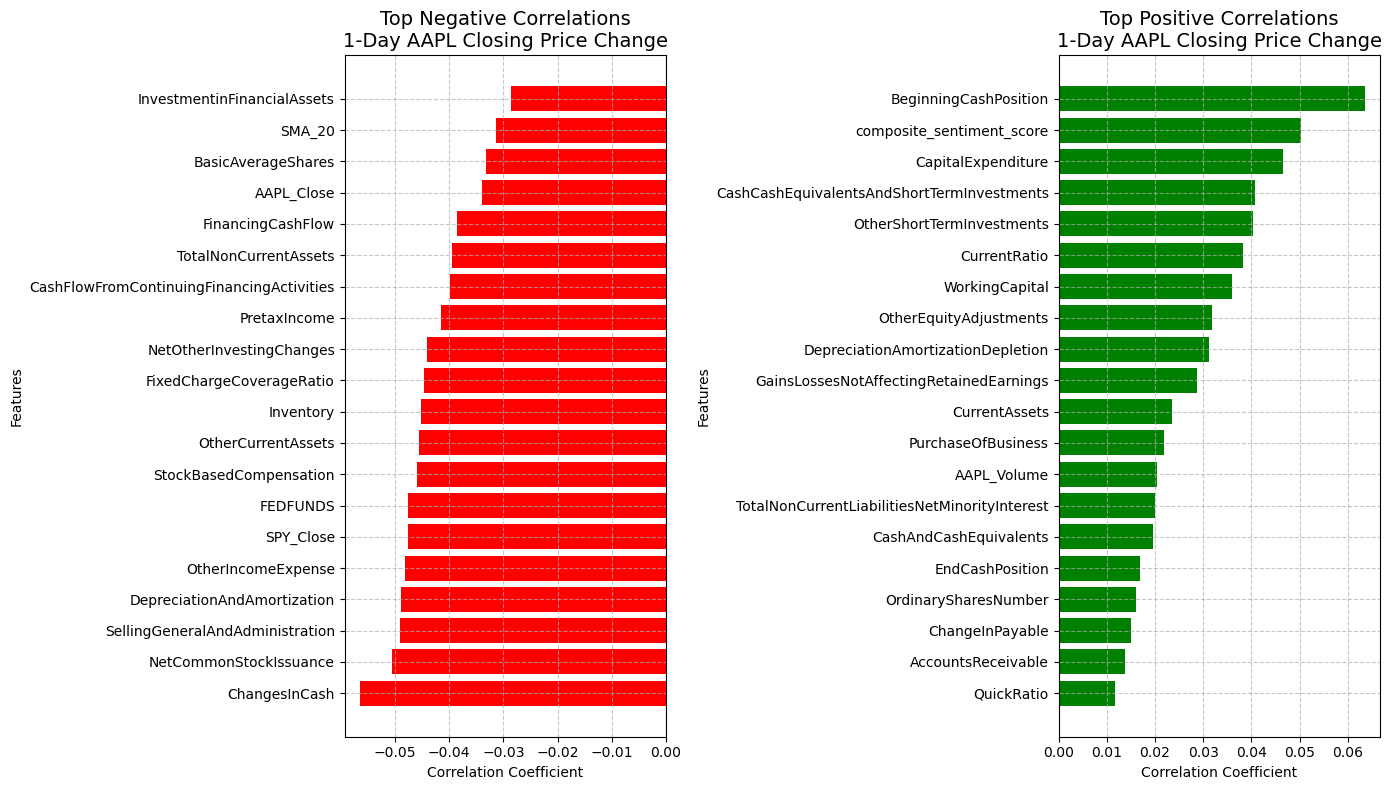

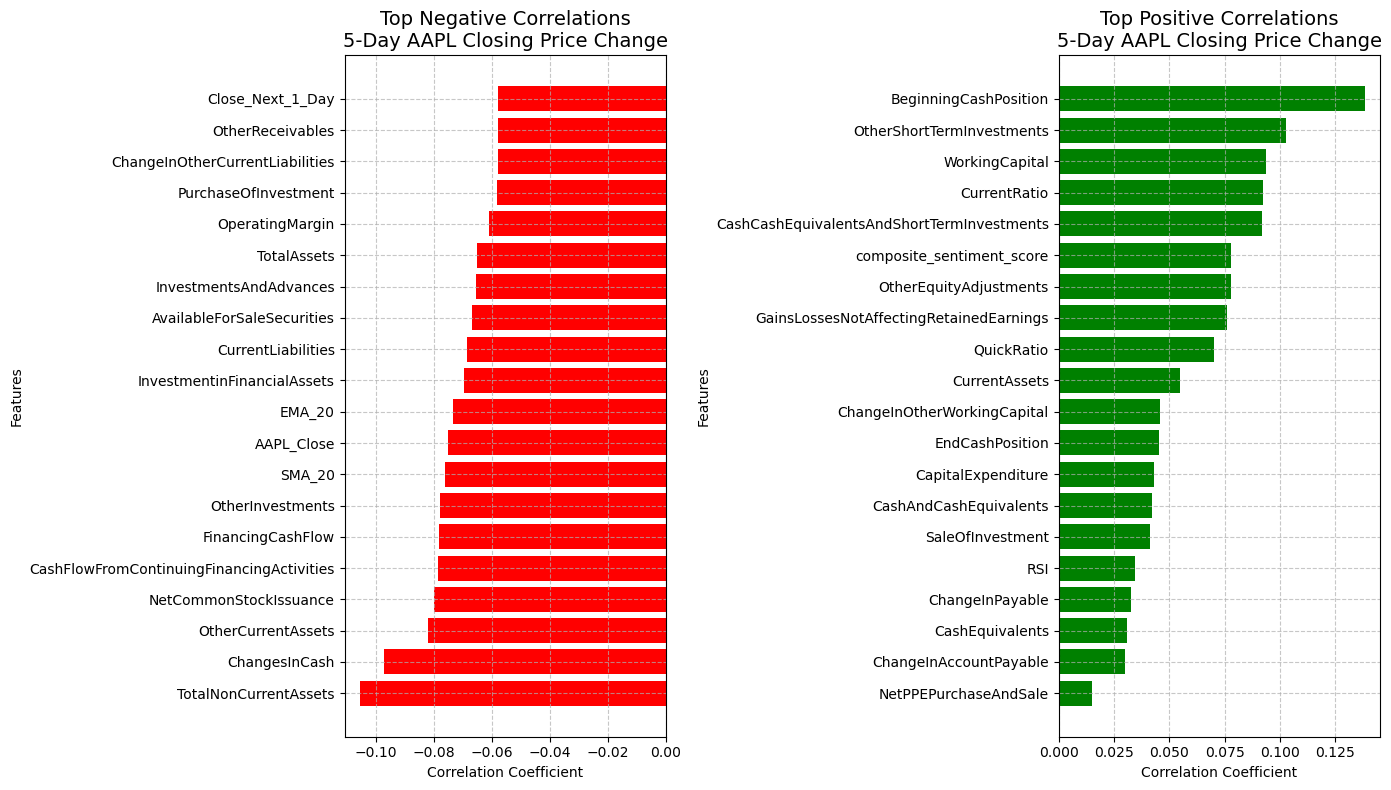

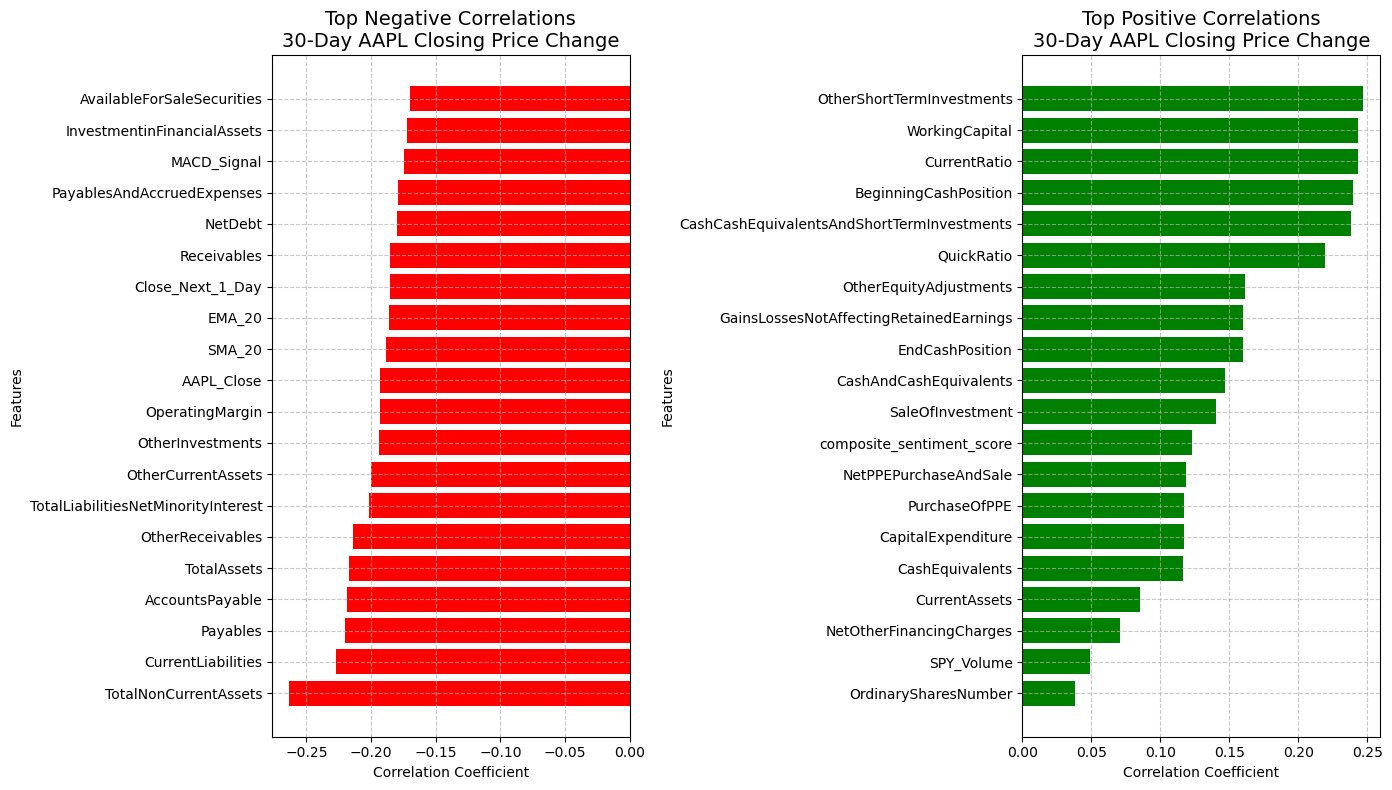

In [8]:
# Plot for Close_Next1_pctchg
plot_top_correlations('1-Day AAPL Closing Price Change',
                      correlation_results['Close_Next1_pctchg'][0],
                      correlation_results['Close_Next1_pctchg'][1])

# Plot for Close_Next5_pctchg
plot_top_correlations('5-Day AAPL Closing Price Change',
                      correlation_results['Close_Next5_pctchg'][0],
                      correlation_results['Close_Next5_pctchg'][1])

# Plot for Close_Next30_pctchg
plot_top_correlations('30-Day AAPL Closing Price Change',
                      correlation_results['Close_Next30_pctchg'][0],
                      correlation_results['Close_Next30_pctchg'][1])

## 5. Technical Trading Indicators vs the Stock

#### Key Findings:

- Technical indicators like SMA_20, EMA_20, RSI, Golden_Cross, MACD, and MACD_Signal show very weak correlations with Close_Next1_pctchg, indicating limited predictive power for immediate future stock movements.

- Similarly, these indicators have weak relationships with Close_Next5_pctchg and Close_Next30_pctchg, though there is a slight improvement in correlation with longer-term changes.

- RSI, which measures momentum, shows almost no predictive correlation with 5-day and 30-day future price changes, suggesting its limited utility for predicting medium to long-term price movements within this dataset.

- MACD and MACD_Signal, closely related in their movements, demonstrate a high correlation with each other but fail to significantly correlate with future stock price changes.

- This pattern suggests that while these indicators are consistent in signaling market conditions, their effectiveness in forecasting exact stock price movements over the analyzed periods is minimal. The lack of strong correlations might indicate the necessity for integrating these technical indicators with other analytical tools or data to enhance predictive capabilities.


Overall, the analysis highlights the challenge of relying solely on traditional technical indicators for predicting stock price movements over varying future intervals.

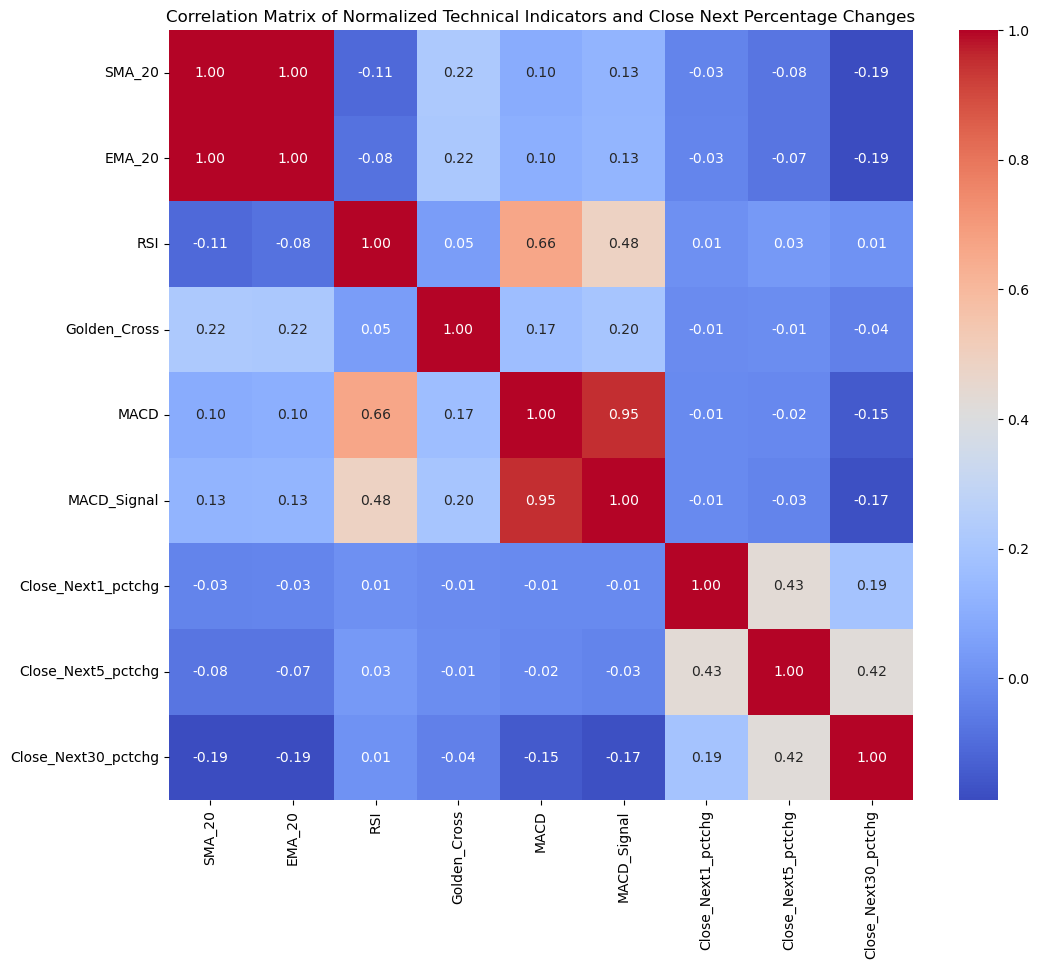

In [104]:
# Select the columns of interest
columns_of_interest = ['SMA_20', 'EMA_20', 'RSI', 'Golden_Cross', 'MACD', 'MACD_Signal',
                       'Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']

# Filter the dataset to include only the columns of interest
data_for_scaling = aapl_master_data[columns_of_interest]

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the data (fit and transform)
normalized_data = scaler.fit_transform(data_for_scaling.fillna(0))  # Handling NaNs by replacing them with 0

# Convert the scaled data back to a DataFrame
normalized_df = pd.DataFrame(normalized_data, columns=columns_of_interest)

# Calculate the correlation matrix from the normalized data
correlation_matrix = normalized_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix of Normalized Technical Indicators and Close Next Percentage Changes')
plt.show()


## 5. FEDFUNDS Rate Influences the Stock

#### Key Findings: 
##### Summary:
##### Immediate Effect: 
- There is a slight positive correlation (about 0.237) between Federal Funds Rate changes and Apple's stock price the next day, indicating a minor immediate boost in stock price following a rate increase.

##### Longer-Term Impact:
- Over 5 days, the correlation becomes slightly negative (-0.138), suggesting a minor adverse effect.
- Over 30 days, the negative impact is even less pronounced (-0.081), indicating a negligible influence of rate changes on stock price.
- Market Dynamics: The analysis shows considerable variability in Apple's stock response to rate changes, with a significant influence from other external factors, especially over longer periods.

##### Conclusion:
Federal Funds Rate changes have a modest and short-lived positive impact on Apple's stock price, with minimal influence over longer durations. This highlights the importance of considering broader market conditions when evaluating stock performance.

In [41]:
# Load the dataset
aapl_master_data = pd.read_csv('AAPL_MasterData- 2018-2023.csv')


# Convert the 'Date' column to datetime format
aapl_master_data['Date'] = pd.to_datetime(aapl_master_data['Date'], errors='coerce')

# Sort the data by date to ensure chronological order
aapl_master_data.sort_values(by='Date', inplace=True)

# Extract the first occurrence of each month
# Use 'Date' as the index to resample and find the first day of each month
first_of_month = aapl_master_data.set_index('Date').resample('MS').first()

# Calculate the log-transformed FEDFUNDS rate
first_of_month['Log_FEDFUNDS'] = np.log(first_of_month['FEDFUNDS'])

# Calculate the log change in FEDFUNDS from the first occurrence of each month
first_of_month['Log_FEDFUNDS_Change'] = first_of_month['Log_FEDFUNDS'].diff()

# Reset the index to merge easily
first_of_month.reset_index(inplace=True)

# Merge the log change back to the original dataset
aapl_master_data = pd.merge(aapl_master_data, first_of_month[['Date', 'Log_FEDFUNDS_Change']], on='Date', how='left')



In [42]:
# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for each Close Next Pctchg column
columns_to_clean = ['Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']
for column in columns_to_clean:
    aapl_master_data = remove_outliers(aapl_master_data, column)

In [43]:
# Ensure Log_FEDFUNDS_Change column is in the DataFrame
assert 'Log_FEDFUNDS_Change' in aapl_master_data.columns, "Log_FEDFUNDS_Change column is missing"

# Calculate correlations with the Close Next Pctchg columns
correlations_log_change = aapl_master_data[['Log_FEDFUNDS_Change', 'Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']].corr()

# Display the correlation matrix
correlations_log_change

,Log_FEDFUNDS_Change,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg
Log_FEDFUNDS_Change,1.000000,0.237697,-0.138537,-0.001196
Close_Next1_pctchg,0.237697,1.000000,0.378797,0.150085
Close_Next5_pctchg,-0.138537,0.378797,1.000000,0.390211
Close_Next30_pctchg,-0.001196,0.150085,0.390211,1.000000


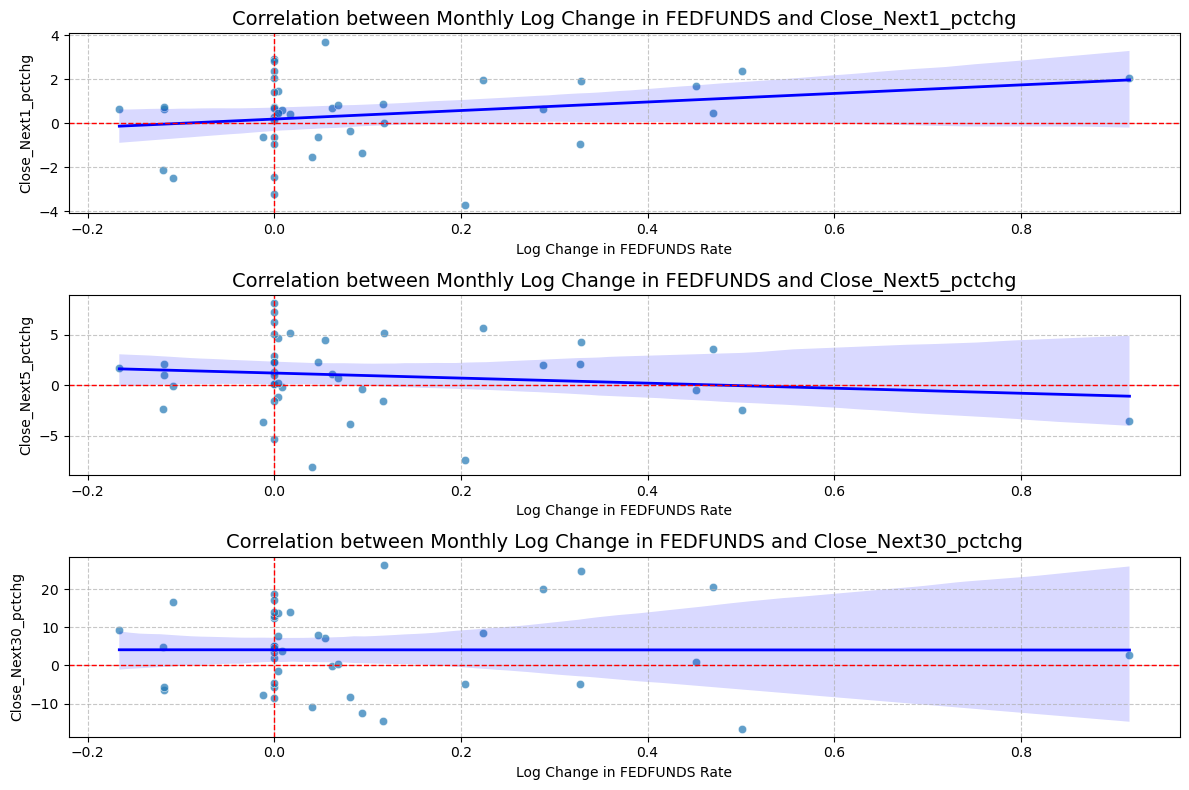

In [44]:
# Visualize the correlation of Log_FEDFUNDS_Change with each of the Close Next Pctchg columns
plt.figure(figsize=(12, 8))

for i, column in enumerate(columns_to_clean, start=1):
    plt.subplot(3, 1, i)
    sns.scatterplot(data=aapl_master_data, x='Log_FEDFUNDS_Change', y=column, alpha=0.7)
    
    # Draw shapes: Add regression line and annotate
    sns.regplot(data=aapl_master_data, x='Log_FEDFUNDS_Change', y=column, scatter=False, color='blue', line_kws={"linewidth": 2})
    plt.title(f'Correlation between Monthly Log Change in FEDFUNDS and {column}', fontsize=14)
    plt.xlabel('Log Change in FEDFUNDS Rate')
    plt.ylabel(f'{column}')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight zero line
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## 6. Market Data Relationship (SPY Overall Market)

#### Key Findings:
- The correlation matrix between log-transformed SPY Close percentage changes and Apple's future closing price changes reveals limited predictive relationships. Daily and 5-day SPY changes show negligible correlation with corresponding AAPL changes, suggesting minimal direct influence of broader market trends on AAPL's stock movements over these periods. 

- However, correlations within AAPL's own metrics across different time frames are more significant, particularly indicating that short-term movements can somewhat predict subsequent performance. The strongest negative correlation observed is between SPY's 30-day change and AAPL's 30-day future price change, although it remains weak, highlighting AAPL's relative independence from broader market movements within the examined timeframe.

In [61]:
# Load the dataset
aapl_master_data = pd.read_csv('AAPL_MasterData- 2018-2023.csv')

# Convert the 'Date' column to datetime format
aapl_master_data['Date'] = pd.to_datetime(aapl_master_data['Date'], errors='coerce')

# Sort the data by date to ensure chronological order
aapl_master_data.sort_values(by='Date', inplace=True)

# Calculate percentage changes for previous 1, 5, and 30 days for SPY_Close
aapl_master_data['SPY_Close_pct_change_1'] = aapl_master_data['SPY_Close'].pct_change(periods=1)
aapl_master_data['SPY_Close_pct_change_5'] = aapl_master_data['SPY_Close'].pct_change(periods=5)
aapl_master_data['SPY_Close_pct_change_30'] = aapl_master_data['SPY_Close'].pct_change(periods=30)

# Handle negative and zero values before log transformation
for col in ['SPY_Close_pct_change_1', 'SPY_Close_pct_change_5', 'SPY_Close_pct_change_30']:
    aapl_master_data[col] = aapl_master_data[col].apply(lambda x: np.nan if x <= 0 else x)

# Drop NaN values
aapl_master_data.dropna(subset=['SPY_Close_pct_change_1', 'SPY_Close_pct_change_5', 'SPY_Close_pct_change_30'], inplace=True)

# Apply log transformation to percentage changes
aapl_master_data['Log_SPY_Close_pct_change_1'] = np.log(aapl_master_data['SPY_Close_pct_change_1'])
aapl_master_data['Log_SPY_Close_pct_change_5'] = np.log(aapl_master_data['SPY_Close_pct_change_5'])
aapl_master_data['Log_SPY_Close_pct_change_30'] = np.log(aapl_master_data['SPY_Close_pct_change_30'])

# Remove outliers using IQR for each log-transformed pct change column
columns_to_clean_log = ['Log_SPY_Close_pct_change_1', 'Log_SPY_Close_pct_change_5', 'Log_SPY_Close_pct_change_30']
for column in columns_to_clean_log:
    aapl_master_data = remove_outliers(aapl_master_data, column)


In [62]:
# Calculate correlations for log-transformed SPY pct changes and Close Next pctchg columns
correlations_log_spy_aapl = aapl_master_data[['Log_SPY_Close_pct_change_1', 'Log_SPY_Close_pct_change_5', 'Log_SPY_Close_pct_change_30', 'Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']].corr()
print("Log-transformed Correlation Matrix:")
correlations_log_spy_aapl

Log-transformed Correlation Matrix:


,Log_SPY_Close_pct_change_1,Log_SPY_Close_pct_change_5,Log_SPY_Close_pct_change_30,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg
Log_SPY_Close_pct_change_1,1.000000,0.219683,0.110916,-0.059139,-0.022737,0.024617
Log_SPY_Close_pct_change_5,0.219683,1.000000,0.150469,-0.029105,0.014829,0.025542
Log_SPY_Close_pct_change_30,0.110916,0.150469,1.000000,0.028141,-0.036764,-0.088462
Close_Next1_pctchg,-0.059139,-0.029105,0.028141,1.000000,0.473094,0.100484
Close_Next5_pctchg,-0.022737,0.014829,-0.036764,0.473094,1.000000,0.294909
Close_Next30_pctchg,0.024617,0.025542,-0.088462,0.100484,0.294909,1.000000


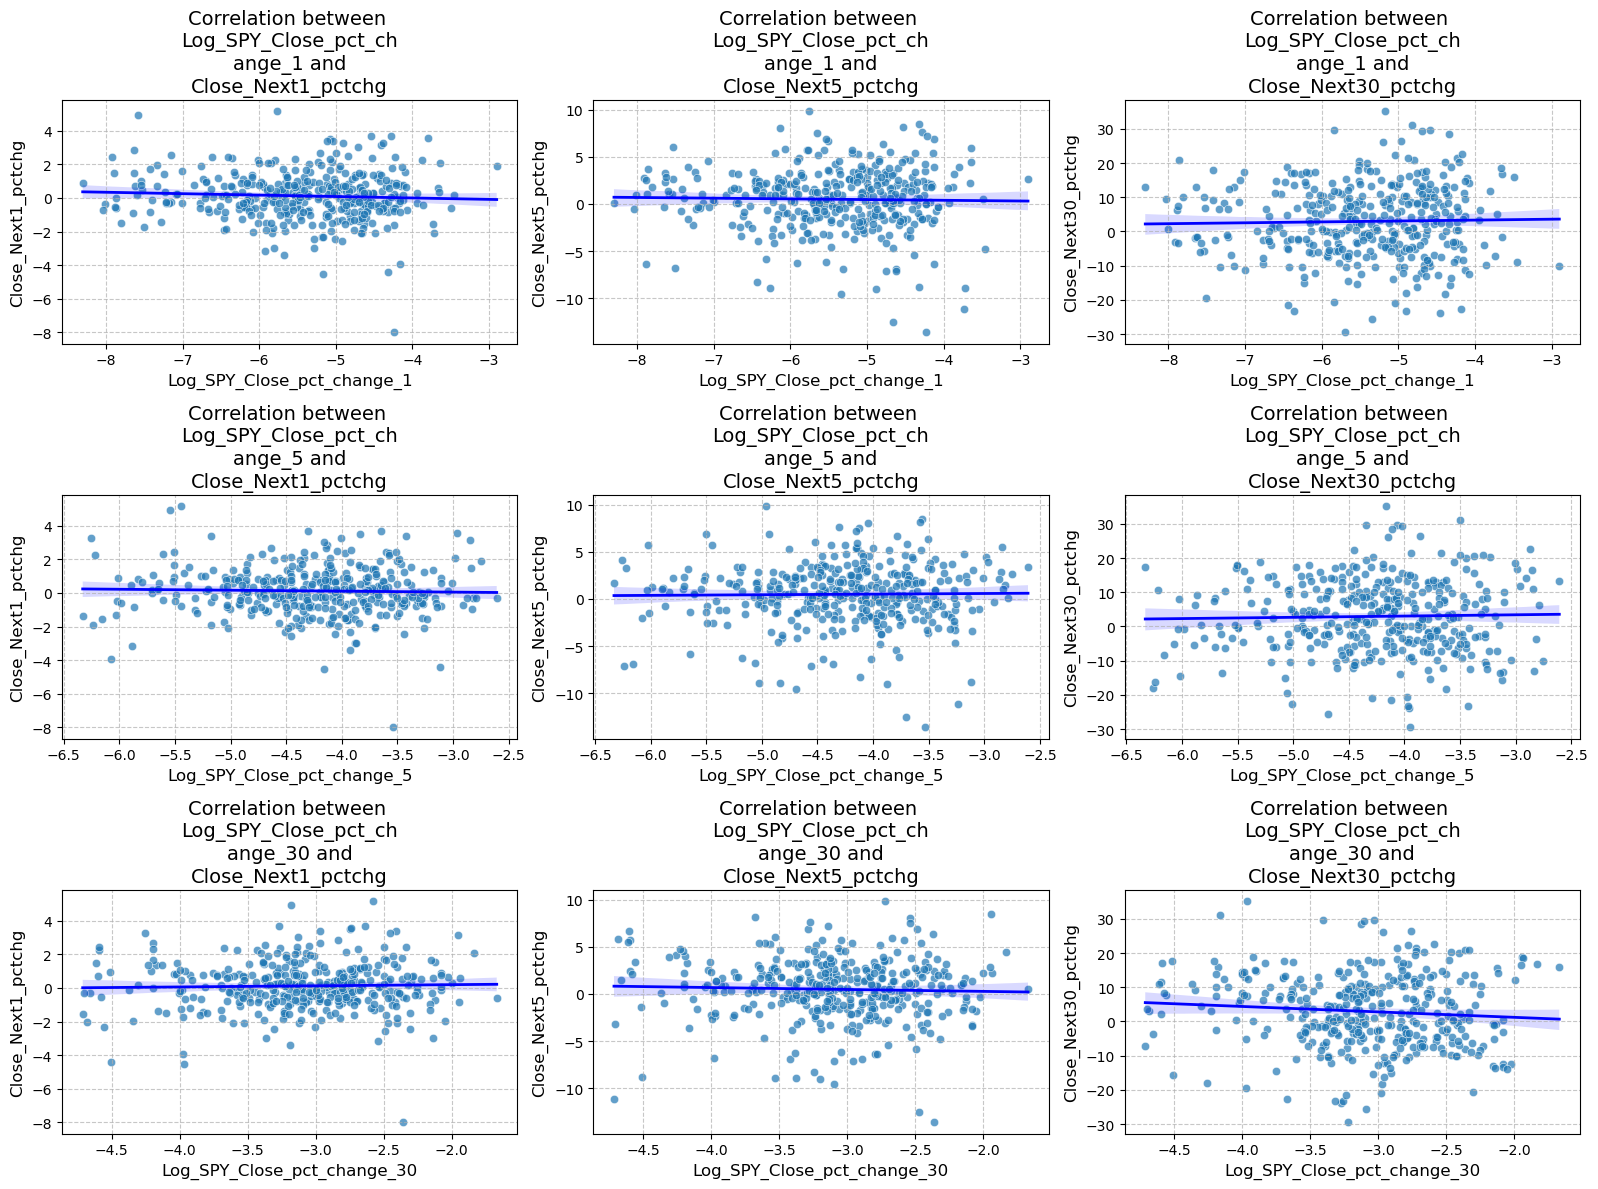

In [63]:
# Visualization setup
plt.figure(figsize=(16, 12))
metrics_log = ['Log_SPY_Close_pct_change_1', 'Log_SPY_Close_pct_change_5', 'Log_SPY_Close_pct_change_30']
pct_chg_cols = ['Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']

# Text wrapping function
def wrap_title(text, width=20):
    return '\n'.join(textwrap.wrap(text, width))

# Visualization loop with text wrapping for titles
for i, metric in enumerate(metrics_log, start=1):
    for j, pct_chg in enumerate(pct_chg_cols, start=1):
        ax = plt.subplot(len(metrics_log), len(pct_chg_cols), (i-1)*len(pct_chg_cols)+j)
        sns.scatterplot(data=aapl_master_data, x=metric, y=pct_chg, alpha=0.7)
        sns.regplot(data=aapl_master_data, x=metric, y=pct_chg, scatter=False, color='blue', line_kws={"linewidth": 2})
        
        # Apply wrapped title
        ax.set_title(wrap_title(f'Correlation between {metric} and {pct_chg}'), fontsize=14)
        ax.set_xlabel(metric, fontsize=12)
        ax.set_ylabel(pct_chg, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Sentiment Analysis on News Articles

In [69]:
# Load the dataset
apple_articles_sentiment = pd.read_csv('apple_articles_with_sentiment.csv')

# Display the first few rows of the dataset
apple_articles_sentiment.head(3)


,date,published_utc,title,description,article_url,author,source,article_content,sentiment_score,sentiment
0,2023-09-08,2023-09-08T07:34:58Z,Mexico Is The New China? SPAC King Chamath Pal...,A couple of developments related to China rock...,https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,Benzinga,"U.S. multinationals, including Apple and Tesl...",-0.055,Negative
1,2021-06-14,2021-06-14T20:06:00Z,Is Apple Setting Up For Fresh Rally Leg?,No Description,https://www.investing.com/analysis/is-apple-se...,Gary S. Morrow,Investing.com,Is Apple (NASDAQ:AAPL) setting up for a fresh ...,0.101,Positive
2,2021-05-28,2021-05-28T01:15:00Z,Dow Jumps Over 140 Points as Jobless Claims Co...,No Description,https://www.investing.com/analysis/dow-jumps-o...,Zacks Investment Research,Investing.com,• Apple Computer (NASDAQ:AAPL),0.000,Neutral


In [72]:
# Check the structure of the dataset
apple_articles_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8683 entries, 0 to 8682
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             8683 non-null   object 
 1   published_utc    8683 non-null   object 
 2   title            8683 non-null   object 
 3   description      8683 non-null   object 
 4   article_url      8683 non-null   object 
 5   author           8683 non-null   object 
 6   source           8683 non-null   object 
 7   article_content  8291 non-null   object 
 8   sentiment_score  8682 non-null   float64
 9   sentiment        8683 non-null   object 
dtypes: float64(1), object(9)
memory usage: 678.5+ KB


In [75]:
# Generate summary statistics (if applicable)
apple_articles_sentiment.describe(include='all')

,date,published_utc,title,description,article_url,author,source,article_content,sentiment_score,sentiment
count,8683,8683,8683,8683,8683,8683,8683,8291,8682.000000,8683
unique,998,8638,8319,7911,8683,524,6,8257,NaN,5
top,2021-09-14,2021-10-09T13:00:00Z,3 Things About Apple That Smart Investors Know,No Description,https://www.benzinga.com/analyst-ratings/analy...,Shanthi Rexaline,The Motley Fool,It could become the mother of all technologica...,NaN,Positive
freq,29,2,13,748,1,566,4559,15,NaN,7264
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.151261,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.128832,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.600000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.070000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.158000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.225000,NaN


In [ ]:
# Remove rows where 'article_content' is null
apple_articles_sentiment = apple_articles_sentiment.dropna(subset=['article_content','sentiment_score'])

# Display the count of null values per column after removal
print("\nNull values after removal of null 'article_content':")
print(apple_articles_sentiment.isnull().sum())


## 7. Articles By Month Trend
#### Key Findings:  Apple news articles by month from November 2018 to December 2023. 

- It reveals a significant period of zero activity from April 2019 to March 2021, suggesting a possible data collection issue or an extraordinary halt in media coverage. 
- Following this gap, there is a sudden surge in article counts starting in April 2021, with numbers dramatically increasing to over 200 articles per month and peaking at 351 articles in September 2021. This spike could indicate that our datasource Polygon.io did not start collecting data until this date. Furthermore, affecting how sentiment can be used on our dataset.








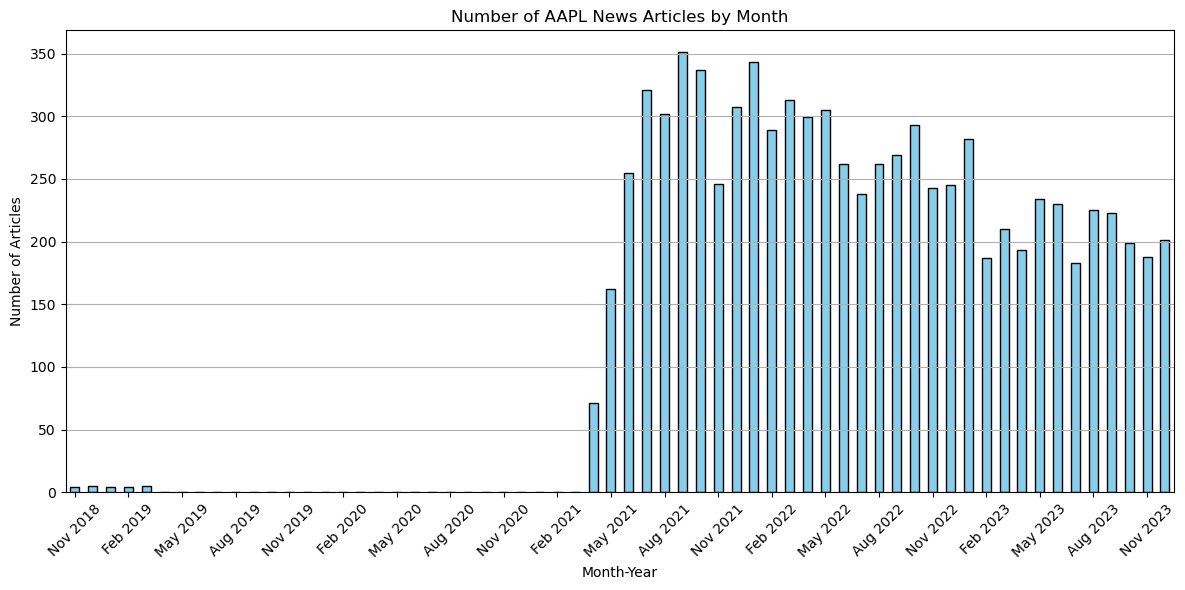

In [88]:
# Convert the 'Date' column to datetime format
apple_articles_sentiment['date'] = pd.to_datetime(apple_articles_sentiment['date'], errors='coerce')

# Group by month and count the number of articles
articles_by_month = apple_articles_sentiment.groupby(pd.Grouper(key='date', freq='M')).size()

# Plot the number of articles by month and year
plt.figure(figsize=(12, 6))
articles_by_month.plot(kind='bar', color='skyblue', edgecolor='black')

# Customize the x-axis to show only every third month
plt.xticks(
    ticks=range(0, len(articles_by_month), 3),
    labels=[date.strftime('%b %Y') for date in articles_by_month.index[::3]],
    rotation=45
)

plt.title('Number of AAPL News Articles by Month')
plt.xlabel('Month-Year')
plt.ylabel('Number of Articles')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Composite Sentiment Score vs Stock Change

#### Key Findings: 

The composite sentiment score shows very weak correlations with Apple's 1-day, 5-day, and 30-day future stock price changes, with values of 0.05, 0.08, and 0.12 respectively, indicating a minimal impact of sentiment on short to medium-term stock movements. In contrast, stock price changes themselves show moderate internal consistency, with a correlation of 0.43 between 1-day and 5-day changes, but this predictability diminishes for longer periods, as shown by the lower correlations for 5-day to 30-day and 1-day to 30-day changes.

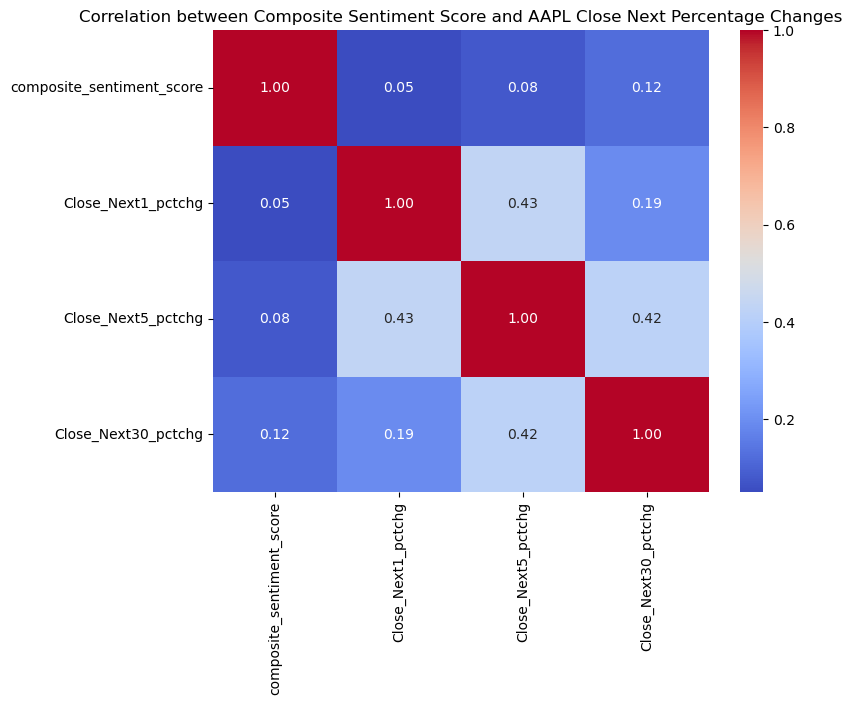

In [101]:
# Convert date column to datetime if necessary
aapl_master_data['Date'] = pd.to_datetime(aapl_master_data['Date'])

# Calculate correlations between sentiment score and the Close_Next_pctchg columns
correlation_matrix = aapl_master_data[['composite_sentiment_score', 'Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg']].corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation between Composite Sentiment Score and AAPL Close Next Percentage Changes')
plt.show()